In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from flonacomldft.utils.io_utils import load_csv_file, load_pickle_file

In [3]:
isomers = torch.arange(0, 1)

train_zmats = [load_csv_file(
    "database/berendsen/converged/is{:d}_flow_train.csv".format(isomer)) 
    for isomer in isomers]
test_zmats = [load_csv_file(
    "database/berendsen/converged/is{:d}_flow_test.csv".format(isomer)) 
    for isomer in isomers]

In [4]:
flow_ids = [20230520201411, 20230525163346] 
dict_flows_init = [load_pickle_file("database/berendsen/models/is{:d}_flow_dic_training_{:d}.pkl".format(isomer, flow_id)) for isomer, flow_id in zip(isomers, flow_ids)]

In [5]:
kb = 8.617333262e-5
T = 300
beta = 1 / (kb * T)
target_energy = lambda x: torch.tensor(-6.8+torch.rand(1)*0.5)


In [6]:
from flonacomldft.models.mixture import Mixture
from flonacomldft.internal_coordinates import join_data
from flonacomldft.sampling import run_metropolis
import copy

In [7]:
from flonacomldft.train_flow_from_data import train_flow

In [8]:
def Transpose(x):
    return x.permute(*torch.arange(x.ndim - 1, -1, -1))

In [9]:
def full_adaptative_sampling(
        flow_init_train,
        flow_init_test,
        init_mcmc,
        dict_flows_init,
        dict_mlps_init,
        flow_hyperparams,
        n_chains,
        n_steps,
        n_runs,
        dim=12,
        energy_type='mlp',
        mixture=False,
        T=300
        ):

    modes = torch.unique(flow_init_train[:, dim+1])

    xs_for_flows_train = [ flow_init_train[flow_init_train[:, dim+1] == mode] for mode in modes ]
    xs_for_flows_test = [ flow_init_test[flow_init_test[:, dim+1] == mode] for mode in modes ]

    dict_flows_training = [copy.deepcopy(dict_flows_init), ]

    flow_models = lambda dict_flows: [dict_flow['model'] for dict_flow in dict_flows]
    mlp_models = lambda dict_mlps: [dict_mlp['model'] for dict_mlp in dict_mlps]

    mcmc_runs = []

    xs = []
    us = []
    accs = []
    isomers = []
    
    init = init_mcmc

    #init = xs_for_flows_test[0][:n_chains]

    for i in range(n_runs):

        if mixture:
            weights = torch.tensor([0.5, 0.5]).detach()
            model = Mixture(flow_models(dict_flows_training[i]), weights)
        else:
            model = flow_models(dict_flows_training[i])[0]

        mcmc_run = run_metropolis(
            model=model,
            init=init,
            n_chains=n_chains,
            n_steps=n_steps,
            id_run=i,
            energy_type=energy_type,
            mlp_models=mlp_models(dict_mlps_init),
            mixture=mixture,
            dim=dim,
            )
        
        mcmc_runs.append(mcmc_run)

        xs.append(mcmc_run["xs"])
        us.append(mcmc_run["us"])
        accs.append(mcmc_run["accs"])
        isomers.append(mcmc_run["isomers"])

        init = join_data(xs[i][-1].clone(), us[i][-1].clone(), isomers[i][-1].clone())

        #TODO: Chech size of xs_for_flows_train

        chains_flatten = Transpose(
            torch.cat(
                (
                    Transpose(xs[i].clone()),
                    Transpose(us[i].clone().reshape(n_steps, n_chains, 1)),
                    Transpose(isomers[i].clone().reshape(n_steps, n_chains, 1)),
                ),
                dim=0,
            )
        )

        chains_flatten = chains_flatten.reshape(n_steps * n_chains, chains_flatten.shape[-1])

        mask_flow = chains_flatten[:, -1]

        dict_new_flows = []

        for mode in modes.detach().numpy().astype(int):

            xs_from_chains = chains_flatten.clone()[mask_flow==mode].clone()

            # extend data set for flow training

            xs_for_flows_train[mode] = torch.cat(
                (xs_for_flows_train[mode].clone(), xs_from_chains.clone())
            )

            #add mlps
            dict_new_flow = train_flow(
                dict_flows_training[i][mode]['model'],
                xs_for_flows_train[mode],
                xs_for_flows_test[mode],
                #mlp_model=get_models(dict_mlps_training[-1])[0],
                **flow_hyperparams[mode],
                dim=dim
                )
            
            dict_new_flows.append(copy.deepcopy(dict_new_flow))
            
        else:
            dict_new_flow = copy.deepcopy(dict_flows_training[i][mode])
            dict_new_flows.append(dict_new_flow)

        dict_flows_training.append(dict_new_flows)

    to_return = {
        "dict_flows_training": dict_flows_training,
        "mcmc_runs": mcmc_runs,
        "xs": xs,
        "us": us,
        "accs": accs,
        "isomers": isomers,
    }

    return to_return

In [10]:
mlp_dic = {'model': target_energy}

In [11]:
flow_hyperparams = {'n_iter': 100,
    'lr': 1e-3,
    'use_scheduler': False,
    'step_schedule': 100,
    'save_splits': 10,
    'grad_clip': 1e4}


In [12]:
from flonacomldft.internal_coordinates import Coordinates_mapping
coord_mapping = Coordinates_mapping()

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Pas

In [13]:
# To real centered data

train_xs = [coord_mapping.get_real_centered_from_internal(
                                    train_zmat[:, :12],
                                    train_zmat[:, 14],
                                    isomer=isomer.item(),
                                    energies=train_zmat[:, 12]
                                    ) for isomer, train_zmat in zip(isomers, train_zmats)]

train_xs = torch.stack(
                        [torch.cat( (
                                        x[0], x[2].reshape(-1, 1), 
                                        zmat_test[:, 13].reshape(-1, 1), 
                                        #x[1].reshape(-1, 1),
                                        ), 
                                        dim=1) 
                        for x, zmat_test in zip(train_xs, train_zmats)]
                    )
# Avoid using 15, add values or shape
train_xs = train_xs.clone().squeeze_().reshape(-1, train_xs.shape[-1]) 



In [14]:
test_xs = [coord_mapping.get_real_centered_from_internal(
                                        test_zmat[:, :12],
                                        test_zmat[:, 14],
                                        isomer=isomer.item(),
                                        energies=test_zmat[:, 12]
                                        ) for isomer, test_zmat in zip(isomers, test_zmats)]

test_xs = torch.stack(
                        [torch.cat((
                                        x[0], x[2].reshape(-1, 1),
                                        zmat_test[:, 13].reshape(-1, 1),
                                        #x[1].reshape(-1, 1),
                                        ),
                                        dim=1)
                                
                        for x, zmat_test in zip(test_xs, test_zmats)]
                )

test_xs = test_xs.clone().squeeze_().reshape(-1, test_xs.shape[-1])


In [15]:
n_runs = 3
n_chains = 5
n_steps = 10

shuffle = torch.randperm(test_xs.shape[0])
init_mcmc = test_xs[shuffle].clone()[:n_chains]

In [16]:
_ = full_adaptative_sampling(train_xs, 
                         test_xs,
                         init_mcmc, 
                         dim=12,
                         dict_flows_init=dict_flows_init,
                         dict_mlps_init=[mlp_dic],
                         mixture=False,
                         flow_hyperparams=[flow_hyperparams, flow_hyperparams],
                         n_runs=n_runs,
                         n_chains=n_chains,
                         n_steps=n_steps,
                         energy_type='dft',
                        )

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Pas

step: 0 	 acc: 0.00
t=0.0e+00 	 loss: -50.85	Gd: 1e+02	lr: 1.00e-03
t=1.0e+01 	 loss: 13.24	Gd: 1e+04	lr: 1.00e-03
t=2.0e+01 	 loss: -29.09	Gd: 5e+03	lr: 1.00e-03
t=3.0e+01 	 loss: -41.40	Gd: 3e+03	lr: 1.00e-03
t=4.0e+01 	 loss: -46.05	Gd: 2e+03	lr: 1.00e-03
t=5.0e+01 	 loss: -47.95	Gd: 1e+03	lr: 1.00e-03
t=6.0e+01 	 loss: -48.91	Gd: 4e+02	lr: 1.00e-03
t=7.0e+01 	 loss: -49.52	Gd: 2e+02	lr: 1.00e-03
t=8.0e+01 	 loss: -49.92	Gd: 3e+02	lr: 1.00e-03
t=9.0e+01 	 loss: -50.23	Gd: 9e+01	lr: 1.00e-03


/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Pas

step: 0 	 acc: 0.20
t=0.0e+00 	 loss: -50.37	Gd: 4e+01	lr: 1.00e-03
t=1.0e+01 	 loss: -29.69	Gd: 4e+03	lr: 1.00e-03
t=2.0e+01 	 loss: -41.16	Gd: 2e+03	lr: 1.00e-03
t=3.0e+01 	 loss: -45.24	Gd: 1e+03	lr: 1.00e-03
t=4.0e+01 	 loss: -47.66	Gd: 6e+02	lr: 1.00e-03
t=5.0e+01 	 loss: -48.67	Gd: 4e+02	lr: 1.00e-03
t=6.0e+01 	 loss: -49.19	Gd: 3e+02	lr: 1.00e-03
t=7.0e+01 	 loss: -49.50	Gd: 2e+02	lr: 1.00e-03
t=8.0e+01 	 loss: -49.80	Gd: 8e+01	lr: 1.00e-03
t=9.0e+01 	 loss: -50.10	Gd: 5e+01	lr: 1.00e-03


/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Pas

step: 0 	 acc: 0.00
t=0.0e+00 	 loss: -50.25	Gd: 5e+01	lr: 1.00e-03
t=1.0e+01 	 loss: -40.70	Gd: 4e+03	lr: 1.00e-03
t=2.0e+01 	 loss: -45.00	Gd: 2e+03	lr: 1.00e-03
t=3.0e+01 	 loss: -47.67	Gd: 1e+03	lr: 1.00e-03
t=4.0e+01 	 loss: -48.23	Gd: 1e+03	lr: 1.00e-03
t=5.0e+01 	 loss: -49.23	Gd: 9e+02	lr: 1.00e-03
t=6.0e+01 	 loss: -50.01	Gd: 2e+02	lr: 1.00e-03
t=7.0e+01 	 loss: -50.13	Gd: 4e+02	lr: 1.00e-03
t=8.0e+01 	 loss: -50.29	Gd: 7e+01	lr: 1.00e-03
t=9.0e+01 	 loss: -50.35	Gd: 7e+01	lr: 1.00e-03


In [17]:
chains_xs = torch.stack(_['xs']).reshape(-1, 12)
chains_us = torch.stack(_['us']).reshape(-1, 1)
chains_isomers = torch.stack(_['isomers']).reshape(-1, 1)

In [18]:
mcmc_xs = torch.cat([chains_xs, chains_us.reshape(-1, 1), chains_isomers.reshape(-1, 1)], dim=1)

In [19]:
mask = mcmc_xs[:, -1].squeeze()

In [28]:
mcmc_zmat = [coord_mapping.get_internal_from_real_centered(mcmc_xs[mcmc_xs[:, -1]==isomer][:, :12],
                                                          isomer=isomer.item(),
                                                          energies=mcmc_xs[mcmc_xs[:, -1]==isomer][:, 12],)
            for isomer in isomers]

mcmc_zmat

[(tensor([[ 2.8052e+00,  2.6603e+00,  2.7768e+00,  ..., -6.3516e-03,
            4.4523e-02, -3.1220e+00],
          [ 2.8068e+00,  2.6616e+00,  2.7743e+00,  ..., -2.9627e-03,
            3.5092e-03, -3.1400e+00],
          [ 2.8206e+00,  2.6798e+00,  2.7569e+00,  ..., -2.9146e-02,
            2.8500e-02, -3.1687e+00],
          ...,
          [ 2.8206e+00,  2.6798e+00,  2.7569e+00,  ..., -2.9146e-02,
            2.8500e-02, -3.1687e+00],
          [ 2.7680e+00,  2.6601e+00,  2.7872e+00,  ...,  3.3751e-02,
           -1.6102e-01, -3.1065e+00],
          [ 2.7723e+00,  2.6630e+00,  2.8174e+00,  ..., -1.7436e-02,
            2.6989e-02, -3.0887e+00]], grad_fn=<AddBackward0>),
  tensor([-0.0029, -0.0002, -0.0032, -0.0004, -0.0011, -0.0029, -0.0002, -0.0032,
          -0.0004, -0.0011, -0.0088, -0.0002, -0.0032, -0.0307, -0.0011, -0.0088,
          -0.0002, -0.0032, -0.0307, -0.0011, -0.0088, -0.0002, -0.0032, -0.0307,
          -0.0011, -0.0088, -0.0002, -0.0032, -0.0307, -0.0011, -0.0088

In [31]:
mcmc_zmat[0][0][0]

tensor([ 2.8052,  2.6603,  2.7768,  2.6639,  2.6816,  1.0256,  2.0680,  2.0916,
         1.0170, -0.0064,  0.0445, -3.1220], grad_fn=<SelectBackward0>)

<AxesSubplot:>

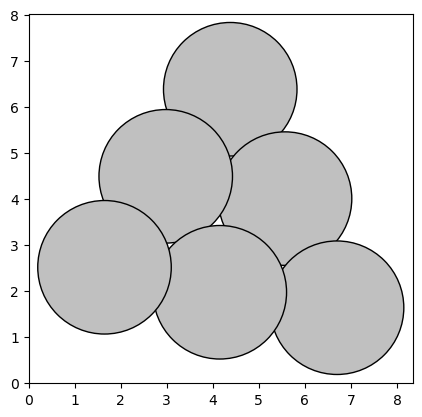

In [32]:
molecule = coord_mapping.build_molecule_from_zmat(mcmc_zmat[0][0][0])

from ase.visualize.plot import plot_atoms
plot_atoms(molecule)

In [33]:
from flonacomldft.collective_variables import get_CVs

In [34]:
cvs = get_CVs(mcmc_zmat[0][0])

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Pas

In [ ]:
from flonacomldft.utils.plots import Flonaco_Plotter

plotter = Flonaco_Plotter()

In [ ]:
np.array(cvs).T[:, 0]

array([10.42778513, 10.48654582, 10.24496253, 10.24067818, 10.27774941,
       10.24496253, 10.33479039, 10.18067717, 10.27774941, 10.24496253,
       10.33479039, 10.31891533, 10.18067717, 10.27774941, 10.24496253,
       10.33479039, 10.2581521 , 10.18067717, 10.27774941, 10.24496253,
       10.33479039, 10.18067717, 10.24496253, 10.33479039, 10.18067717,
       10.15933831, 10.31970853, 10.18067717, 10.43547677, 10.15933831,
       10.31970853, 10.18067717, 10.43547677, 10.15933831, 10.31970853,
       10.18067717, 10.43547677, 10.15933831, 10.31970853, 10.18067717,
       10.43547677, 10.15933831, 10.31970853, 10.18067717, 10.43547677,
       10.15933831, 10.31970853, 10.18067717, 10.43547677, 10.15933831,
       10.31970853, 10.18067717, 10.43547677, 10.06138838, 10.31970853,
       10.18067717, 10.43547677, 10.06138838, 10.31970853, 10.26543546,
       10.43547677, 10.06138838, 10.31970853, 10.26543546, 10.43547677,
       10.06138838, 10.17453942, 10.26543546, 10.43547677, 10.06

<class 'list'>


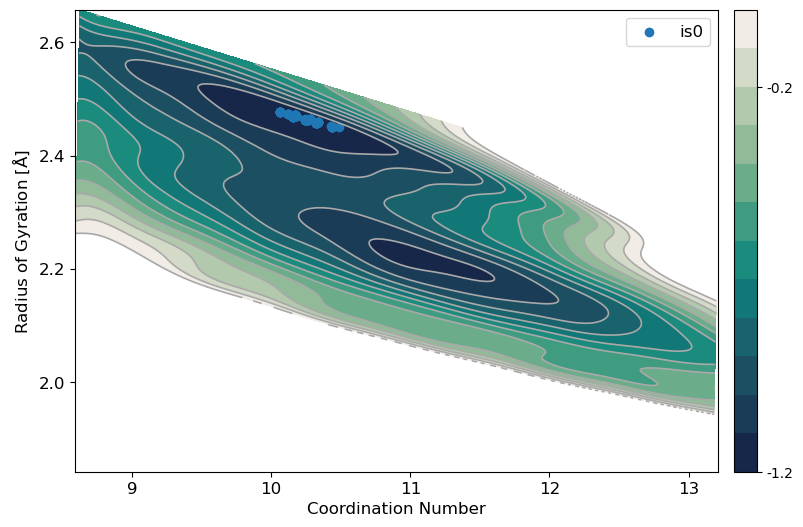

In [ ]:
plotter.plot_collective_variables_on_fes(np.array(cvs).T, label='is0')